# v3 Results — Same Regularization, Full Epoch Budget

Traffic Sign Classifier (GTSRB) — identical setup to v2 (augmentation, dropout p=0.5, early stopping patience=5), but with `num_epochs=80` (instead of an artificial cap of 30) and `num_workers=4` for faster data loading. Early stopping triggered naturally this run.

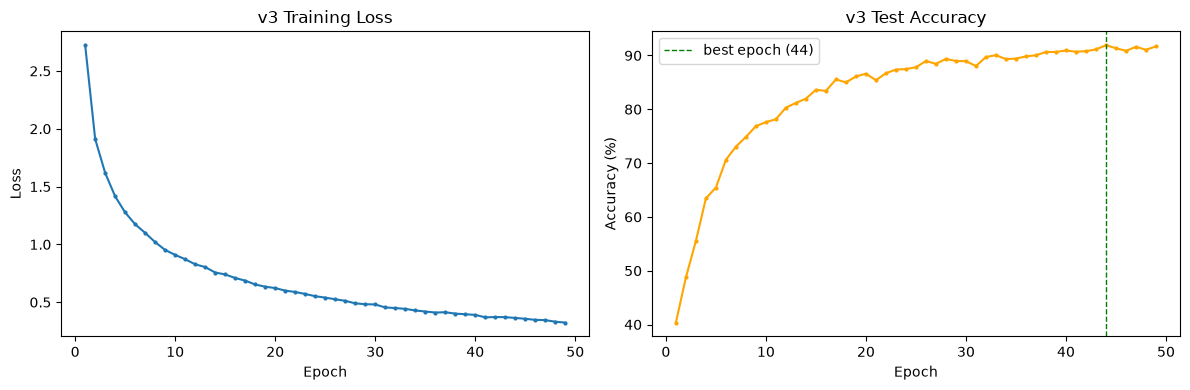

In [1]:
import matplotlib.pyplot as plt

epochs_v3 = list(range(1, 50))
train_loss_v3 = [2.7227, 1.9113, 1.6177, 1.4147, 1.2760, 1.1739, 1.0994, 1.0191, 0.9517, 0.9090,
                  0.8716, 0.8276, 0.8040, 0.7569, 0.7401, 0.7093, 0.6865, 0.6532, 0.6341, 0.6224,
                  0.6000, 0.5886, 0.5712, 0.5519, 0.5397, 0.5253, 0.5121, 0.4903, 0.4826, 0.4805,
                  0.4547, 0.4496, 0.4425, 0.4287, 0.4194, 0.4107, 0.4130, 0.4013, 0.3958, 0.3905,
                  0.3691, 0.3719, 0.3705, 0.3640, 0.3565, 0.3473, 0.3450, 0.3314, 0.3234]
test_acc_v3 = [40.35, 48.75, 55.53, 63.45, 65.45, 70.61, 73.06, 74.86, 76.87, 77.61,
               78.16, 80.31, 81.18, 81.98, 83.63, 83.41, 85.55, 85.01, 86.10, 86.61,
               85.41, 86.70, 87.38, 87.47, 87.81, 88.97, 88.44, 89.37, 88.96, 88.95,
               88.04, 89.71, 90.06, 89.32, 89.42, 89.83, 90.04, 90.66, 90.65, 90.93,
               90.70, 90.80, 91.13, 91.91, 91.35, 90.86, 91.61, 91.06, 91.69]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_v3, train_loss_v3, marker='o', markersize=2)
axes[0].set_title('v3 Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_v3, test_acc_v3, marker='o', markersize=2, color='orange')
axes[1].axvline(x=44, color='green', linestyle='--', linewidth=1, label='best epoch (44)')
axes[1].set_title('v3 Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## v1 vs v2 vs v3 comparison

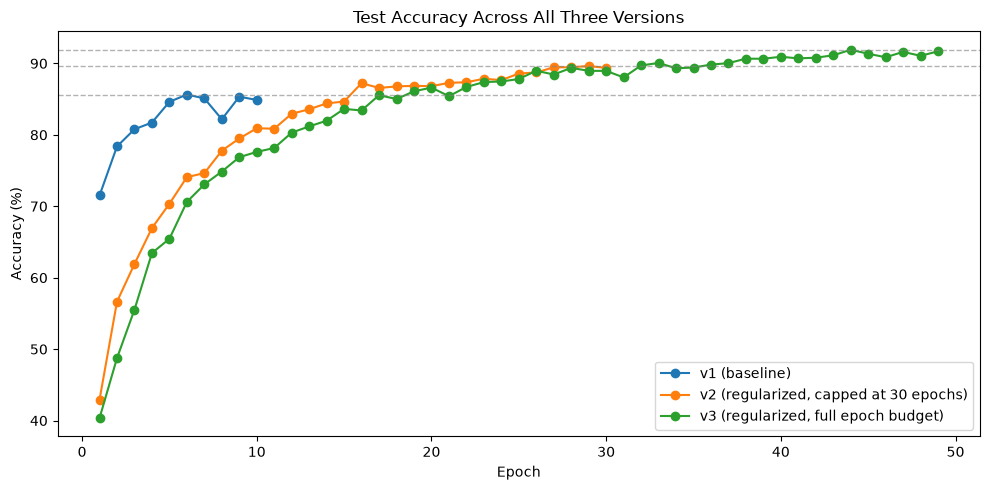

Summary:
  v1 peak: 85.64% (epoch 6)
  v2 peak: 89.63% (epoch 29, epoch-capped)
  v3 peak: 91.91% (epoch 44, early stopping triggered naturally)


In [2]:
epochs_v1 = list(range(1, 11))
test_acc_v1 = [71.51, 78.38, 80.78, 81.72, 84.62, 85.64, 85.10, 82.18, 85.34, 84.88]

epochs_v2 = list(range(1, 31))
test_acc_v2 = [42.93, 56.65, 61.92, 66.95, 70.35, 74.08, 74.64, 77.78, 79.49, 80.92,
               80.86, 82.95, 83.58, 84.40, 84.66, 87.24, 86.56, 86.78, 86.86, 86.81,
               87.28, 87.36, 87.85, 87.66, 88.58, 88.73, 89.45, 89.46, 89.63, 89.37]

plt.figure(figsize=(10, 5))
plt.plot(epochs_v1, test_acc_v1, marker='o', label='v1 (baseline)')
plt.plot(epochs_v2, test_acc_v2, marker='o', label='v2 (regularized, capped at 30 epochs)')
plt.plot(epochs_v3, test_acc_v3, marker='o', label='v3 (regularized, full epoch budget)')
plt.axhline(y=85.64, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(y=89.63, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(y=91.91, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.title('Test Accuracy Across All Three Versions')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

print('Summary:')
print(f'  v1 peak: 85.64% (epoch 6)')
print(f'  v2 peak: 89.63% (epoch 29, epoch-capped)')
print(f'  v3 peak: 91.91% (epoch 44, early stopping triggered naturally)')

## Interpretation

*Despite using the same architecture and regulations as V2, V3 outperformed it by ( 2.28% )which shows the need for a higher epoch number in order for the early stopping technique to work instead of guessing a random ceiling in V2 *